In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT))

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: /Users/ryant/Github/ryantjx/cuthberto-carlos


In [2]:
from model_factsmc import build_factsmc_model
from scripts.smc.process_data import process_data_pl
import jax
from tqdm import tqdm
import cuthbert

# Offline Filtering

In [3]:
import polars as pl

N = 100

# Load training data (2020-2024) and test data (2024-2026)
# This ensures consistent team IDs across both datasets
pl_data, jax_data, pl_data_future, jax_data_future, id_to_name = process_data_pl(
    train_start="2020-01-01",
    train_end="2026-06-10",
    test_end="2026-07-19",
    max_goals=8,
)

print(f"Training matches: {len(pl_data)}")
print(f"Test/future matches: {len(pl_data_future)}")
print(f"Number of teams: {len(id_to_name)}")

pl_data.filter(
    (pl.col("home_team") == "England") | (pl.col("away_team") == "England")
).head(5)

Training matches: 6001
Test/future matches: 89
Number of teams: 262


date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,friendly,timestamp_days,home_timestamp_previous,away_timestamp_previous,home_team_id,away_team_id
date,str,str,i64,i64,str,str,str,bool,bool,i64,i64,i64,i64,i64
2020-09-05,"""Iceland""","""England""",0,1,"""UEFA Nations League""","""Reykjavík""","""Iceland""",false,false,242,12,0,104,68
2020-09-08,"""Denmark""","""England""",0,0,"""UEFA Nations League""","""Copenhagen""","""Denmark""",false,false,245,242,242,59,68
2020-10-08,"""England""","""Wales""",3,0,"""Friendly""","""London""","""England""",false,true,275,245,243,68,252
2020-10-11,"""England""","""Belgium""",2,1,"""UEFA Nations League""","""London""","""England""",false,false,278,275,275,68,22
2020-10-14,"""England""","""Denmark""",0,1,"""UEFA Nations League""","""London""","""England""",false,false,281,278,278,68,59


In [4]:
pl_data_future.head(5)

date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,friendly,timestamp_days,home_timestamp_previous,away_timestamp_previous,home_team_id,away_team_id
date,str,str,i64,i64,str,str,str,bool,bool,i64,i64,i64,i64,i64
2026-06-11,"""Mexico""","""South Africa""",2,0,"""FIFA World Cup""","""Mexico City""","""Mexico""",false,false,2347,2340,2342,149,210
2026-06-11,"""South Korea""","""Czech Republic""",2,1,"""FIFA World Cup""","""Zapopan""","""Mexico""",true,false,2347,2339,2340,211,57
2026-06-12,"""Canada""","""Bosnia and Herzegovina""",1,1,"""FIFA World Cup""","""Toronto""","""Canada""",false,false,2348,2341,2342,40,30
2026-06-12,"""United States""","""Paraguay""",4,1,"""FIFA World Cup""","""Inglewood""","""United States""",false,false,2348,2342,2341,244,176
2026-06-13,"""Qatar""","""Switzerland""",1,1,"""FIFA World Cup""","""Santa Clara""","""United States""",true,false,2349,2342,2342,182,218


In [5]:
num_teams = len(id_to_name)

from scripts.smc.fact_smc.model_factsmc import (
    INIT_MEAN,
    INIT_COV,
    INITIAL_KAPPA,
    INITIAL_ALPHA,
    INITIAL_BETA,
    FRIENDLY_SCALE,
    NEUTRAL_SCALE,
)

params = {
    'init_mean': INIT_MEAN,
    'init_cov': INIT_COV,
    'kappa': INITIAL_KAPPA,
    'alpha': INITIAL_ALPHA,
    'beta': INITIAL_BETA,
    'friendly_scale': FRIENDLY_SCALE,
    'neutral_scale': NEUTRAL_SCALE,
}

smc_filter, factorializer = build_factsmc_model(params=params, N=N, num_teams=num_teams)

keys = jax.random.split(jax.random.PRNGKey(0), num_teams)

In [6]:
# init_state: (F, N, 2)
# local_states: (T, F, N, 2)
# final_state: (F, N, 2)

init_state, local_states, final_state = cuthbert.factorial.filter(
    filter_obj=smc_filter,
    factorializer=factorializer,
    model_inputs=jax_data,
    output_factorial=False,
    key=jax.random.PRNGKey(0)
)

In [23]:
type(local_states)

cuthbert.smc.particle_filter.ParticleFilterState

In [8]:
local_states.log_weights.shape

(6000, 2, 100)

In [9]:
import numpy as np

# local_states.particles: (T, 2, N, 2) — timesteps × (home, away) × particles × (attack, defence)
# local_states.log_weights: (T, 2, N)
# Timestep t in local_states corresponds to match index t+1 in jax_data (index 0 = init)

particles = np.array(local_states.particles)       # (T, 2, N, 2)
log_weights = np.array(local_states.log_weights)   # (T, 2, N)
weights = np.exp(log_weights - log_weights.max(axis=-1, keepdims=True))
weights = weights / weights.sum(axis=-1, keepdims=True)  # normalise per (T, F)

T, F, N, D = particles.shape

# Build index arrays
t_idx = np.arange(T) + 1  # +1 because local_states[0] = match index 1
home_ids = np.array(jax_data.home_team_id)[t_idx]
away_ids = np.array(jax_data.away_team_id)[t_idx]
timestamps = np.array(jax_data.timestamp)[t_idx]

# Factor 0 = home, factor 1 = away
team_ids = np.stack([home_ids, away_ids], axis=1)  # (T, 2)

# Broadcast to (T, 2, N)
ts_b = np.broadcast_to(timestamps[:, None, None], (T, F, N))
team_b = np.broadcast_to(team_ids[:, :, None], (T, F, N))
attack_b = particles[..., 0]
defence_b = particles[..., 1]
weight_b = weights

# Map team_id → country name via numpy lookup
id_name = {int(k): v for k, v in id_to_name.items()}
max_id = max(id_name.keys()) + 1
name_lut = np.array([id_name.get(i, f"Team {i}") for i in range(max_id)], dtype=object)
country_b = name_lut[team_b]  # (T, 2, N)

origin_date = pl_data["date"].min()

# Flatten to rows
df_local = pl.DataFrame({
    "timestamp": ts_b.ravel(),
    "country": country_b.ravel(),
    "attack": attack_b.ravel(),
    "defence": defence_b.ravel(),
    "weight": weight_b.ravel(),
}).with_columns(
    (pl.lit(origin_date) + pl.col("timestamp").cast(pl.Int64) * pl.duration(days=1)).alias("date")
)

df_local

timestamp,country,attack,defence,weight,date
i32,str,f32,f32,f32,date
2,"""Moldova""",-0.014374,0.817605,0.034071,2020-01-09
2,"""Moldova""",-0.139268,2.275576,0.008365,2020-01-09
2,"""Moldova""",0.593158,0.799232,0.001811,2020-01-09
2,"""Moldova""",0.141573,0.031442,0.010849,2020-01-09
2,"""Moldova""",-0.187955,-1.47967,0.000318,2020-01-09
…,…,…,…,…,…
2346,"""Pakistan""",0.668544,-0.485626,0.011004,2026-06-10
2346,"""Pakistan""",0.724543,-0.683656,0.004705,2026-06-10
2346,"""Pakistan""",1.895281,0.66849,0.012128,2026-06-10


In [10]:
df_local_group = df_local.group_by(["date", "country"]).agg([
    pl.col("attack").mean().alias("attack_mean"),
    pl.col("defence").mean().alias("defence_mean"),
    pl.col("weight").sum().alias("weight_sum"),
    (pl.col("attack") + pl.col("defence")).mean().alias("skill_mean")
])
df_local_group

date,country,attack_mean,defence_mean,weight_sum,skill_mean
date,str,f32,f32,f32,f32
2024-01-24,"""Tunisia""",-0.24495,0.720645,1.0,0.475696
2024-03-21,"""United States""",-0.284171,0.268117,1.0,-0.016054
2024-03-22,"""United States Virgin Islands""",-0.237906,-0.245959,1.0,-0.483865
2021-05-27,"""Turkey""",0.324323,-0.407434,1.0,-0.083111
2025-10-11,"""Iraq""",-0.154829,0.499159,1.0,0.344329
…,…,…,…,…,…
2025-12-28,"""Sudan""",-0.830688,-0.019558,1.0,-0.850245
2025-12-31,"""Burkina Faso""",-0.112708,0.288116,1.0,0.175408
2026-01-04,"""Cameroon""",-0.046665,0.53157,1.0,0.484905


## skill over time

In [11]:
import altair as alt

alt.data_transformers.disable_max_rows()

# Filter the data first
filtered_df = df_local_group.filter(
    pl.col("country").is_in(["England", "Germany", "France", "Italy", "Spain"])
)

# Create line chart with thin dotted lines using polars syntax
line_chart = filtered_df.plot.line(
    x="date",
    y="skill_mean",
    color="country",
).mark_line(
    strokeDash=[2, 2],  # Dotted pattern
    strokeWidth=1       # Thin line
)

# Create scatter chart for circles using polars syntax
point_chart = filtered_df.plot.scatter(
    x="date",
    y="skill_mean",
    color="country",
).mark_circle(size=30)

h_line = alt.Chart().mark_rule(color='black', strokeDash=[4, 4]).encode(y=alt.datum(0))

# Layer them together and make interactive
chart_skill = (line_chart + point_chart + h_line).properties(
    width=800,   # Increase width
    height=400,  # Increase height
).interactive()  # Enable zoom/pan
chart_skill.title = "Estimated Skill Over Time"
chart_skill

/Users/ryant/Github/ryantjx/cuthberto-carlos/.venv/lib/python3.13/site-packages/altair/vegalite/v6/api.py:3807: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  dct = self.to_dict(context={"pre_transform": False})


alt.LayerChart(...)

## current skill level

In [12]:
# Get the most recent skill estimate for each team from df_local_group
# This contains all teams' final skill estimates after filtering through all matches

df_latest = df_local_group.sort("date", descending=True).group_by("country").agg([
    pl.col("attack_mean").first().alias("attack_mean"),
    pl.col("defence_mean").first().alias("defence_mean"),
    pl.col("date").first().alias("date"),
    pl.col("date").count().alias("num_matches")
]).with_columns(
    (pl.col("attack_mean") + pl.col("defence_mean")).alias("total_skill")
)

# Create horizontal bar chart with attack (red) and defense (blue) as stacked bars
df_top20 = df_latest.sort("total_skill", descending=True).head(20)

# Melt the data to long format for stacked bars
df_top20_melted = df_top20.melt(
    id_vars=["country", "date", "num_matches"],
    value_vars=["attack_mean", "defence_mean"],
    variable_name="skill_type",
    value_name="skill_value"
).with_columns(
    pl.col("skill_type").str.replace("attack_mean", "Attack").str.replace("defence_mean", "Defense")
)

# Create color scale: red for Attack, blue for Defense
color_scale = alt.Scale(
    domain=["Attack", "Defense"],
    range=["#e74c3c", "#3498db"]  # Red for attack, blue for defense
)

chart_highest = alt.Chart(df_top20_melted).mark_bar().encode(
    x=alt.X("skill_value:Q", title="Skill Value"),
    y=alt.Y("country:N", sort=alt.EncodingSortField(field="skill_value", op="sum", order="descending")),
    color=alt.Color("skill_type:N", scale=color_scale, title="Skill Type"),
    tooltip=["country", "skill_type", "skill_value", "date", "num_matches"]
).properties(
    width=600,
    height=300,
    title="Current Team Skill Levels - Attack (Red) vs Defense (Blue) (Top 20)"
).interactive()

# Print latest games played for top 20
print("Latest Games Played (Top 20 Teams):")
print(df_top20.select(["country", "date", "attack_mean", "defence_mean", "total_skill", "num_matches"]).sort("total_skill", descending=True))

chart_highest



Latest Games Played (Top 20 Teams):
shape: (20, 6)
┌─────────────┬────────────┬─────────────┬──────────────┬─────────────┬─────────────┐
│ country     ┆ date       ┆ attack_mean ┆ defence_mean ┆ total_skill ┆ num_matches │
│ ---         ┆ ---        ┆ ---         ┆ ---          ┆ ---         ┆ ---         │
│ str         ┆ date       ┆ f32         ┆ f32          ┆ f32         ┆ u32         │
╞═════════════╪════════════╪═════════════╪══════════════╪═════════════╪═════════════╡
│ Morocco     ┆ 2026-06-07 ┆ 0.610904    ┆ 1.037794     ┆ 1.648699    ┆ 89          │
│ Turkey      ┆ 2026-06-06 ┆ 0.519073    ┆ 0.904906     ┆ 1.423979    ┆ 73          │
│ Germany     ┆ 2026-06-06 ┆ 0.835882    ┆ 0.56621      ┆ 1.402093    ┆ 75          │
│ Argentina   ┆ 2026-06-09 ┆ 0.34702     ┆ 0.761397     ┆ 1.108418    ┆ 75          │
│ Pakistan    ┆ 2026-06-10 ┆ 0.451021    ┆ 0.652066     ┆ 1.103087    ┆ 24          │
│ …           ┆ …          ┆ …           ┆ …            ┆ …           ┆ …           │
│ N

/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_83708/1703379047.py:17: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df_top20_melted = df_top20.melt(


alt.Chart(...)

In [13]:
df_latest.filter(pl.col("country") == "Spain")

country,attack_mean,defence_mean,date,num_matches,total_skill
str,f32,f32,date,u32,f32
"""Spain""",0.196719,0.354438,2026-06-08,80,0.551157


In [14]:
df_lowest20 = df_latest.sort("total_skill", descending=False).head(20)

# Melt the data to long format for stacked bars
df_lowest20_melted = df_lowest20.melt(
    id_vars=["country", "date", "num_matches"],
    value_vars=["attack_mean", "defence_mean"],
    variable_name="skill_type",
    value_name="skill_value"
).with_columns(
    pl.col("skill_type").str.replace("attack_mean", "Attack").str.replace("defence_mean", "Defense")
)

# Create color scale: red for Attack, blue for Defense
color_scale = alt.Scale(
    domain=["Attack", "Defense"],
    range=["#e74c3c", "#3498db"]  # Red for attack, blue for defense
)

# Create horizontal bar chart with attack (red) and defense (blue) as stacked bars
chart_lowest = alt.Chart(df_lowest20_melted).mark_bar().encode(
    x=alt.X("skill_value:Q", title="Skill Value"),
    y=alt.Y("country:N", sort=alt.EncodingSortField(field="skill_value", op="sum", order="ascending")),
    color=alt.Color("skill_type:N", scale=color_scale, title="Skill Type"),
    tooltip=["country", "skill_type", "skill_value", "date", "num_matches"]
).properties(
    width=600,
    height=300,
    title="Current Team Skill Levels - Attack (Red) vs Defense (Blue) (Bottom 20)"
).interactive()

chart_lowest

/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_83708/2539572647.py:4: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df_lowest20_melted = df_lowest20.melt(


alt.Chart(...)

# Prediction

In [15]:
pl_data_future

date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,friendly,timestamp_days,home_timestamp_previous,away_timestamp_previous,home_team_id,away_team_id
date,str,str,i64,i64,str,str,str,bool,bool,i64,i64,i64,i64,i64
2026-06-11,"""Mexico""","""South Africa""",2,0,"""FIFA World Cup""","""Mexico City""","""Mexico""",false,false,2347,2340,2342,149,210
2026-06-11,"""South Korea""","""Czech Republic""",2,1,"""FIFA World Cup""","""Zapopan""","""Mexico""",true,false,2347,2339,2340,211,57
2026-06-12,"""Canada""","""Bosnia and Herzegovina""",1,1,"""FIFA World Cup""","""Toronto""","""Canada""",false,false,2348,2341,2342,40,30
2026-06-12,"""United States""","""Paraguay""",4,1,"""FIFA World Cup""","""Inglewood""","""United States""",false,false,2348,2342,2341,244,176
2026-06-13,"""Qatar""","""Switzerland""",1,1,"""FIFA World Cup""","""Santa Clara""","""United States""",true,false,2349,2342,2342,182,218
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-07-02,"""Switzerland""","""Algeria""",-1,-1,"""FIFA World Cup""","""Vancouver""","""Canada""",true,false,2368,2360,2363,218,3
2026-07-03,"""Australia""","""Egypt""",-1,-1,"""FIFA World Cup""","""Arlington""","""United States""",true,false,2369,2361,2362,12,65
2026-07-03,"""Argentina""","""Cape Verde""",-1,-1,"""FIFA World Cup""","""Miami Gardens""","""United States""",true,false,2369,2363,2362,9,41


In [16]:
from scripts.smc.fact_smc.model_factsmc import propagate_and_predict_factsmc
from jax import tree
MAX_GOALS = 8

# Example: Predict a single match
# Get the first future match
match = pl_data_future.row(0, named=True)
home_team_id = match["home_team_id"]
away_team_id = match["away_team_id"]

print(f"\nPredicting match: {match['home_team']} vs {match['away_team']}")
print(f"Match date: {match['date']} ({match['timestamp_days']})")
print(f"Home team ID: {home_team_id}, Away team ID: {away_team_id}")

# Generate prediction
key = jax.random.PRNGKey(42)
prediction = propagate_and_predict_factsmc(
    final_state=final_state,
    factorializer=factorializer,
    match_data = tree.map(lambda x: x[0], jax_data_future),
    params=params,
    n_samples=10000,
    max_goals=MAX_GOALS,
    key=key
)

print("\n--- Prediction Results ---")
print(f"P(Home win): {prediction['probs_results'][0]:.3f}")
print(f"P(Draw):     {prediction['probs_results'][1]:.3f}")
print(f"P(Away win): {prediction['probs_results'][2]:.3f}")
print(f"\nExpected goals: {prediction['expected_home_goals']:.2f} - {prediction['expected_away_goals']:.2f}")
print(f"\nHome team skills (attack, defence): {prediction['home_skills_mean']}")
print(f"Away team skills (attack, defence): {prediction['away_skills_mean']}")


Predicting match: Mexico vs South Africa
Match date: 2026-06-11 (2347)
Home team ID: 149, Away team ID: 210

--- Prediction Results ---
P(Home win): 0.488
P(Draw):     0.346
P(Away win): 0.132

Expected goals: 1.45 - 0.49

Home team skills (attack, defence): [0.35113403 0.93666697]
Away team skills (attack, defence): [-0.5312398   0.58819485]


In [17]:
import jax.numpy as jnp

# Get the actual observed goals from the match data
actual_home_goals = match["home_score"]
actual_away_goals = match["away_score"]

# Get the probability of the observed score from the probs_grid
# probs_grid shape is (max_goals+1, max_goals+1) = (away_goals, home_goals)
observed_prob = prediction["probs_grid"][actual_away_goals, actual_home_goals]

# Compute negative log-likelihood
nll = -jnp.log(observed_prob + 1e-10)  # Add small epsilon to avoid log(0)

print(f"Observed score: {actual_home_goals}-{actual_away_goals}")
print(f"P(observed score): {observed_prob:.4f}")
print(f"Negative log-likelihood: {nll:.4f}")

Observed score: 2-0
P(observed score): 0.0185
Negative log-likelihood: 3.9912


/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_83708/3036290876.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


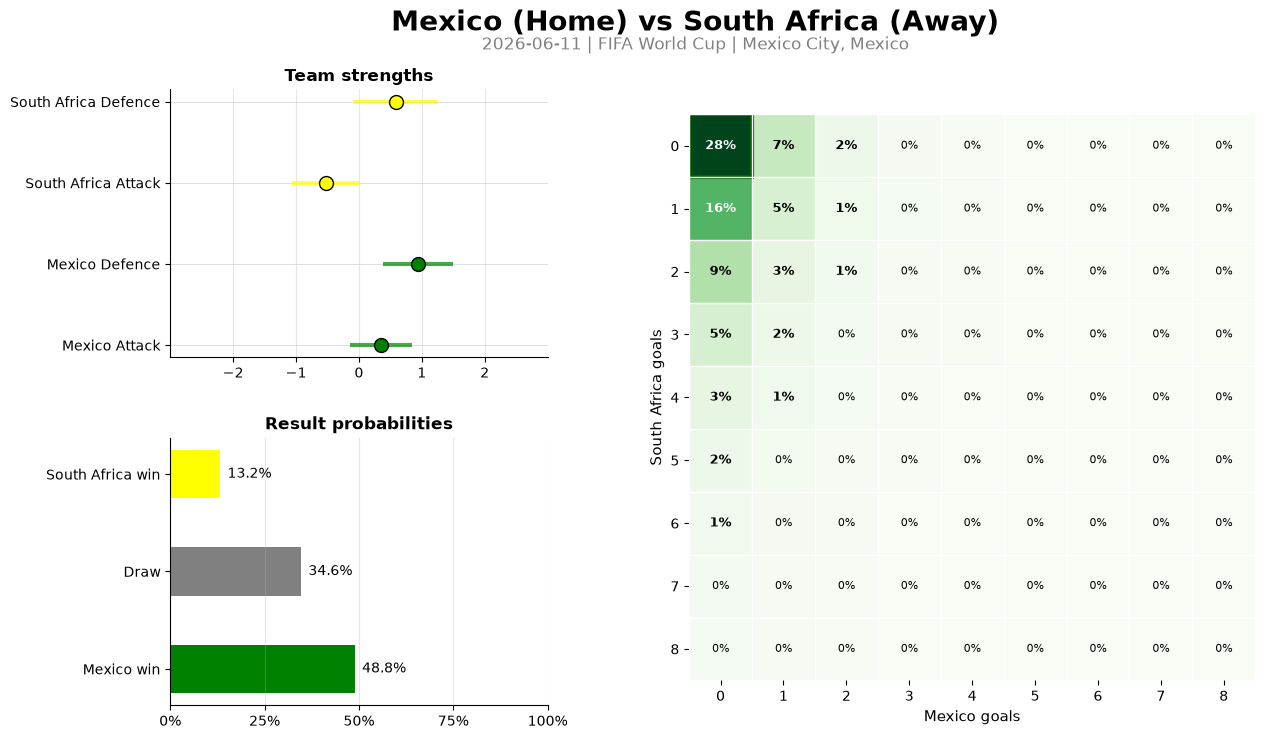

Match: Mexico vs South Africa
Date: 2026-06-11
------------------------------------------------------------
Most Likely Score: 0-0 (28.1%)
Expected Goals: 1.45 - 0.49
Result Probabilities: Mexico win 48.8%, Draw 34.6%, South Africa win 13.2%


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from matplotlib.patches import Rectangle

def plot_match_prediction(prediction, match_info=None, max_goals=8, tournament="FIFA World Cup", location=None):
    """Plot a comprehensive match prediction visualization similar to the example.
    
    Args:
        prediction: Dictionary with 'probs_grid', 'probs_results', 'home_skills_mean', etc.
        match_info: Optional dict with 'home_team', 'away_team', 'date'
        max_goals: Maximum goals in the grid
        tournament: Tournament name for title
        location: Match location for title
    """
    probs_grid = np.array(prediction['probs_grid'])
    probs_results = np.array(prediction['probs_results'])
    
    home_team = match_info.get('home_team', 'Home') if match_info else 'Home'
    away_team = match_info.get('away_team', 'Away') if match_info else 'Away'
    match_date = match_info.get('date', '') if match_info else ''
    
    # Get team skills
    home_skills = np.array(prediction.get('home_skills_mean', [0, 0]))
    away_skills = np.array(prediction.get('away_skills_mean', [0, 0]))
    home_skills_std = np.array(prediction.get('home_skills_std', [0, 0]))
    away_skills_std = np.array(prediction.get('away_skills_std', [0, 0]))
    
    # Calculate 25th and 75th percentiles (assuming normal distribution)
    # For a normal distribution: Q25 = mean - 0.6745 * std, Q75 = mean + 0.6745 * std
    home_1std = 0.6745 * home_skills_std
    away_1std = 0.6745 * away_skills_std

    
    # Create figure with custom grid layout
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1.5], hspace=0.3, wspace=0.3)
    
    # Title
    fig.suptitle(f'{home_team} (Home) vs {away_team} (Away)', fontsize=20, fontweight='bold', y=0.98)
    subtitle = f'{match_date} | {tournament}'
    if location:
        subtitle += f' | {location}'
    fig.text(0.5, 0.93, subtitle, ha='center', fontsize=12, color='gray')
    
    # Top left: Team strengths with quantile ranges
    ax_strengths = fig.add_subplot(gs[0, 0])
    
    # Prepare data for dot plot
    categories = [f'{home_team} Attack', f'{home_team} Defence', 
                  f'{away_team} Attack', f'{away_team} Defence']
    values = [home_skills[0], home_skills[1], away_skills[0], away_skills[1]]
    stdplus1_values = [home_skills[0] - home_1std[0], home_skills[1] - home_1std[1], away_skills[0] - away_1std[0], away_skills[1] - away_1std[1]]
    stdminus1_values = [home_skills[0] + home_1std[0], home_skills[1] + home_1std[1], away_skills[0] + away_1std[0], away_skills[1] + away_1std[1]]
    colors = ['green', 'green', 'yellow', 'yellow']
    
    y_pos = np.arange(len(categories))
    
    # Plot horizontal lines for each category (background grid)
    for i in range(len(categories)):
        ax_strengths.hlines(y=i, xmin=-3, xmax=3, color='lightgray', linewidth=0.5)
    
    # Plot quantile ranges as horizontal lines
    for i, (q25, q75, color) in enumerate(zip(stdplus1_values, stdminus1_values, colors)):
        ax_strengths.hlines(y=i, xmin=q25, xmax=q75, color=color, linewidth=3, alpha=0.7)
    
    # Plot mean values as circles
    for i, (val, color) in enumerate(zip(values, colors)):
        ax_strengths.plot(val, i, 'o', color=color, markersize=10, markeredgecolor='black', markeredgewidth=1, zorder=5)
    
    ax_strengths.set_yticks(y_pos)
    ax_strengths.set_yticklabels(categories)
    ax_strengths.set_xlim(-3, 3)
    ax_strengths.set_xticks([-2, -1, 0, 1, 2])
    ax_strengths.set_title('Team strengths', fontsize=12, fontweight='bold')
    ax_strengths.spines['top'].set_visible(False)
    ax_strengths.spines['right'].set_visible(False)
    ax_strengths.grid(axis='x', alpha=0.3)
    
    # Bottom left: Result probabilities
    ax_results = fig.add_subplot(gs[1, 0])
    
    result_labels = [f'{home_team} win', 'Draw', f'{away_team} win']
    result_colors = ['green', 'gray', 'yellow']
    result_values = probs_results * 100  # Convert to percentage
    
    y_pos = np.arange(len(result_labels))
    bars = ax_results.barh(y_pos, result_values, color=result_colors, height=0.5)
    
    # Add percentage labels
    for i, (bar, val) in enumerate(zip(bars, result_values)):
        ax_results.text(val + 2, i, f'{val:.1f}%', va='center', fontsize=10)
    
    ax_results.set_yticks(y_pos)
    ax_results.set_yticklabels(result_labels)
    ax_results.set_xlim(0, 100)
    ax_results.set_xticks([0, 25, 50, 75, 100])
    ax_results.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax_results.set_title('Result probabilities', fontsize=12, fontweight='bold')
    ax_results.spines['top'].set_visible(False)
    ax_results.spines['right'].set_visible(False)
    ax_results.grid(axis='x', alpha=0.3)
    
    # Right side: Score probability grid
    ax_grid = fig.add_subplot(gs[:, 1])
    
    # Create custom colormap (light green to dark green)
    from matplotlib.colors import LinearSegmentedColormap
    colors_cmap = ['#f7fcf5', '#e5f5e0', '#c7e9c0', '#a1d99b', '#74c476', '#41ab5d', '#238b45', '#006d2c', '#00441b']
    cmap = LinearSegmentedColormap.from_list('greens', colors_cmap)
    
    # Plot heatmap
    im = ax_grid.imshow(probs_grid, cmap=cmap, aspect='equal', vmin=0, vmax=probs_grid.max())
    
    # Add grid lines
    for i in range(max_goals + 1):
        ax_grid.axhline(y=i - 0.5, color='white', linewidth=1)
        ax_grid.axvline(x=i - 0.5, color='white', linewidth=1)
    
    # Add percentage text annotations
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            prob_pct = probs_grid[i, j] * 100
            if prob_pct >= 1:  # Show actual percentage if >= 1%
                text_color = 'white' if prob_pct > probs_grid.max() * 50 else 'black'
                ax_grid.text(j, i, f'{prob_pct:.0f}%',
                           ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')
            else:  # Show 0% for small probabilities
                ax_grid.text(j, i, '0%',
                           ha='center', va='center', color='black', fontsize=8)
    
    # Highlight most likely score
    max_idx = np.unravel_index(np.argmax(probs_grid), probs_grid.shape)
    rect = Rectangle((max_idx[1] - 0.5, max_idx[0] - 0.5), 1, 1, 
                     fill=False, edgecolor='darkgreen', linewidth=3)
    ax_grid.add_patch(rect)
    
    ax_grid.set_xlabel(f'{home_team} goals', fontsize=11)
    ax_grid.set_ylabel(f'{away_team} goals', fontsize=11)
    ax_grid.set_xticks(np.arange(max_goals + 1))
    ax_grid.set_yticks(np.arange(max_goals + 1))
    ax_grid.set_xticklabels(range(max_goals + 1))
    ax_grid.set_yticklabels(range(max_goals + 1))
    
    # Remove spines
    for spine in ax_grid.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    
    # Print summary
    print("=" * 60)
    print(f"Match: {home_team} vs {away_team}")
    print(f"Date: {match_date}")
    print("-" * 60)
    print(f"Most Likely Score: {max_idx[0]}-{max_idx[1]} ({probs_grid[max_idx]:.1%})")
    print(f"Expected Goals: {prediction['expected_home_goals']:.2f} - {prediction['expected_away_goals']:.2f}")
    print(f"Result Probabilities: {home_team} win {probs_results[0]:.1%}, Draw {probs_results[1]:.1%}, {away_team} win {probs_results[2]:.1%}")
    print("=" * 60)


# Example usage
plot_match_prediction(prediction, match_info=match, max_goals=MAX_GOALS, tournament="FIFA World Cup", location="Mexico City, Mexico")

In [21]:
# Batch predict all future matches

def predict_all_future_matches(
    final_state,
    factorializer,
    jax_data_future,
    pl_data_future,
    params: dict[str, jax.Array],
    n_samples: int = 1000,
    max_goals: int = MAX_GOALS,
    key: jax.Array = jax.random.PRNGKey(0),
):
    """Predict all future matches from the final filter state.
    
    Returns a list of prediction dictionaries with match info.
    """
    num_matches = len(jax_data_future.match_index)
    predictions = []
    
    for i in range(num_matches):
        home_team_id = int(jax_data_future.home_team_id[i])
        away_team_id = int(jax_data_future.away_team_id[i])        
        match_info = pl_data_future.row(i, named=True)
        
        # Generate a unique key for each match
        match_key = jax.random.fold_in(key, i)
        
        prediction = propagate_and_predict_factsmc(
            final_state=final_state,
            factorializer=factorializer,
            match_data=tree.map(lambda x: x[i], jax_data_future),
            params=params,
            n_samples=n_samples,
            max_goals=max_goals,
            key=match_key
        )
        prediction["match_info"] = {
            "home_team": match_info["home_team"],
            "away_team": match_info["away_team"],
            "date": match_info["date"],
        }
        predictions.append(prediction)
        
        if (i + 1) % 10 == 0:
            print(f"Predicted {i + 1}/{num_matches} matches...")
    
    return predictions


# Run batch prediction on all future matches
print(f"Predicting all {len(pl_data_future)} future matches...\n")
key = jax.random.PRNGKey(123)
all_predictions = predict_all_future_matches(
    final_state=final_state,
    factorializer=factorializer,
    jax_data_future=jax_data_future,
    pl_data_future=pl_data_future,
    params=params,
    key=key,
    n_samples=1000,
    max_goals=MAX_GOALS,
)

# Display first 5 predictions
print("\n" + "="*60)
print("Sample Predictions (first 5 matches):")
print("="*60)
for pred in all_predictions[:5]:
    info = pred["match_info"]
    probs = pred["probs_results"]
    print(f"\n{info['home_team']} vs {info['away_team']} ({info['date']})")
    print(f"  P(Home): {probs[0]:.3f}, P(Draw): {probs[1]:.3f}, P(Away): {probs[2]:.3f}")
    print(f"  Expected: {pred['expected_home_goals']:.2f} - {pred['expected_away_goals']:.2f}")

Predicting all 89 future matches...

Predicted 10/89 matches...
Predicted 20/89 matches...
Predicted 30/89 matches...
Predicted 40/89 matches...
Predicted 50/89 matches...
Predicted 60/89 matches...
Predicted 70/89 matches...
Predicted 80/89 matches...

Sample Predictions (first 5 matches):

Mexico vs South Africa (2026-06-11)
  P(Home): 0.491, P(Draw): 0.343, P(Away): 0.129
  Expected: 1.46 - 0.50

South Korea vs Czech Republic (2026-06-11)
  P(Home): 0.392, P(Draw): 0.209, P(Away): 0.325
  Expected: 1.67 - 1.47

Canada vs Bosnia and Herzegovina (2026-06-12)
  P(Home): 0.419, P(Draw): 0.338, P(Away): 0.215
  Expected: 1.18 - 0.72

United States vs Paraguay (2026-06-12)
  P(Home): 0.239, P(Draw): 0.212, P(Away): 0.457
  Expected: 1.17 - 1.84

Qatar vs Switzerland (2026-06-13)
  P(Home): 0.212, P(Draw): 0.314, P(Away): 0.438
  Expected: 0.74 - 1.39


In [22]:
nlls = []
for i, pred in enumerate(all_predictions):
    # Get actual result from pl_data_future
    actual = pl_data_future.row(i, named=True)
    if actual["home_score"] == -1 or actual["away_score"] == -1:
        print(f"Skipping match {actual['date']}: {actual['home_team']} vs {actual['away_team']} (no actual score yet)")
        continue
    home_goals = actual["home_score"]
    away_goals = actual["away_score"]

    # Get predicted probability of this score
    prob = pred["probs_grid"][away_goals, home_goals]
    
    # Compute NLL
    nll = -jnp.log(prob + 1e-10)
    nlls.append(float(nll))

mean_nll = jnp.mean(jnp.array(nlls))
print(f"Mean predictive NLL: {mean_nll:.4f}")

Skipping match 2026-06-30: Ivory Coast vs Norway (no actual score yet)
Skipping match 2026-06-30: France vs Sweden (no actual score yet)
Skipping match 2026-06-30: Mexico vs Ecuador (no actual score yet)
Skipping match 2026-07-01: England vs DR Congo (no actual score yet)
Skipping match 2026-07-01: Belgium vs Senegal (no actual score yet)
Skipping match 2026-07-01: United States vs Bosnia and Herzegovina (no actual score yet)
Skipping match 2026-07-02: Spain vs Austria (no actual score yet)
Skipping match 2026-07-02: Portugal vs Croatia (no actual score yet)
Skipping match 2026-07-02: Switzerland vs Algeria (no actual score yet)
Skipping match 2026-07-03: Australia vs Egypt (no actual score yet)
Skipping match 2026-07-03: Argentina vs Cape Verde (no actual score yet)
Skipping match 2026-07-03: Colombia vs Ghana (no actual score yet)
Skipping match 2026-07-04: Canada vs Morocco (no actual score yet)
Mean predictive NLL: 3.6429


# Smoothing

obtaining parameters for model using smoothing. use particle EM